In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv('CSV_FILES/removed.csv')
df

,Unnamed: 0,age,gender,item purchased,category,purchase amount (usd),location,size,color,season,review rating,subscription status,shipping type,discount applied,previous purchases,payment method,frequency of purchases
0,0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly
1,1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly
2,2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly
3,3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly
4,4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,32,Venmo,Weekly
3896,3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,41,Bank Transfer,Bi-Weekly
3897,3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,24,Venmo,Quarterly
3898,3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,24,Venmo,Weekly


In [3]:
df['payment method'].value_counts()

payment method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64

In [4]:
(df['payment method'].value_counts(normalize=True) * 100).round(2)

payment method
PayPal           17.36
Credit Card      17.21
Cash             17.18
Debit Card       16.31
Venmo            16.26
Bank Transfer    15.69
Name: proportion, dtype: float64

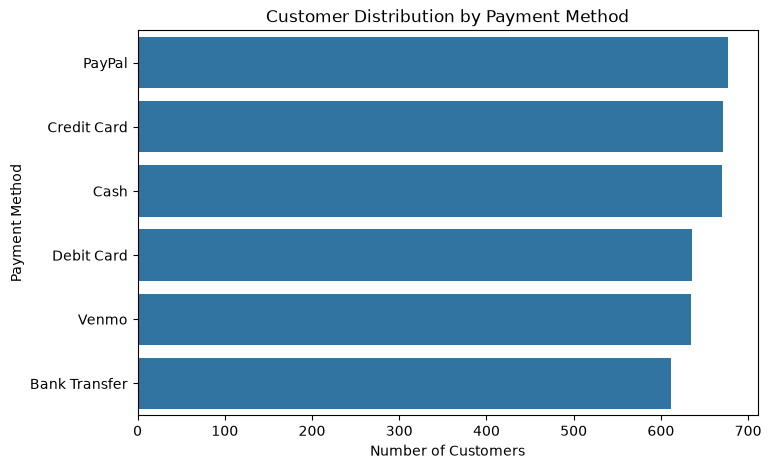

In [5]:
plt.figure(figsize=(8,5))

sns.countplot(
    y='payment method',
    data=df,
    order=df['payment method'].value_counts().index
)

plt.title('Customer Distribution by Payment Method')
plt.xlabel('Number of Customers')
plt.ylabel('Payment Method')

plt.show()

In [7]:
payment_avg = (
    df.groupby('payment method')['purchase amount (usd)']
      .mean()
      .sort_values(ascending=False)
)

payment_avg


payment_revenue = (
    df.groupby('payment method')['purchase amount (usd)']
      .sum()
      .sort_values(ascending=False)
)

payment_revenue

payment method
Credit Card      40310
PayPal           40109
Cash             40002
Debit Card       38742
Venmo            37374
Bank Transfer    36544
Name: purchase amount (usd), dtype: int64

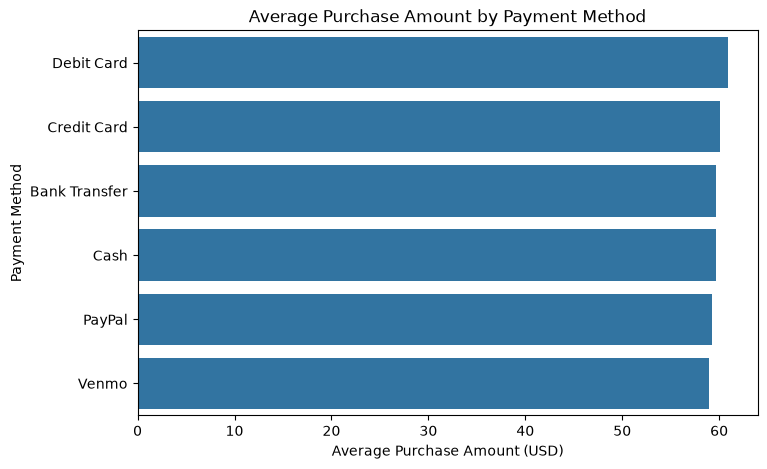

In [8]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=payment_avg.values,
    y=payment_avg.index
)

plt.title('Average Purchase Amount by Payment Method')
plt.xlabel('Average Purchase Amount (USD)')
plt.ylabel('Payment Method')

plt.show()

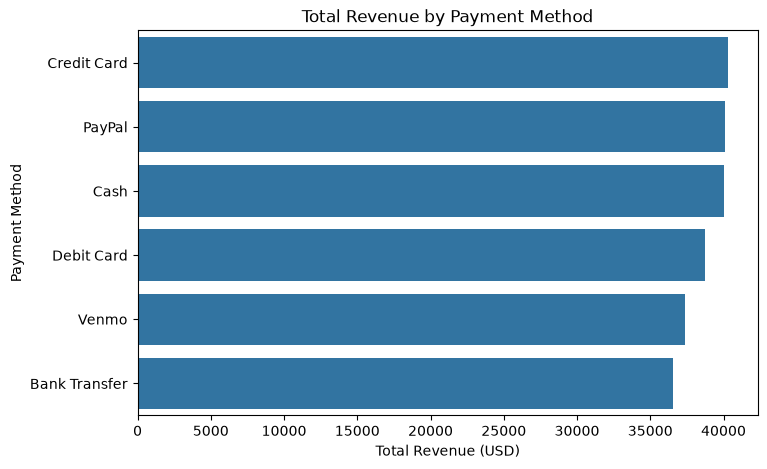

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=payment_revenue.values,
    y=payment_revenue.index
)

plt.title('Total Revenue by Payment Method')
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Payment Method')

plt.show()